In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.6 MB/s eta 0:00:00


In [41]:
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #we are using random forest so standard scaler is not much necessary we will skip it
from sklearn.datasets import load_diabetes

In [3]:
#dataset laoding
#dataset url
url="https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']
df=pd.read_csv(url,names=columns)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#lets check missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
# i want to check whihc columns has values 0
total=0
zero_value_columns=[]
for i in df.columns:
  if(df[i]==0).any():
    total+=1
    print(f"Column: {i} has value of 0")
    zero_value_columns.append(i)
print(f"Total: {total} ")
print(zero_value_columns)

Column: Pregnancies has value of 0
Column: Glucose has value of 0
Column: BloodPressure has value of 0
Column: SkinThickness has value of 0
Column: Insulin has value of 0
Column: BMI has value of 0
Column: Outcome has value of 0
Total: 7 
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Outcome']


In [7]:
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [8]:
#replace 0 with nan so we can handle missing values
df[cols_with_missing_vals]=df[cols_with_missing_vals].replace(0,np.nan)

In [9]:
#let check missing values now
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
df.fillna(df.mean(),inplace=True)

In [11]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


In [13]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [14]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47


In [15]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [16]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,1


In [17]:
#split the dataset into train and test
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
#shapes of data
X_train.shape,X_test.shape

((537, 8), (231, 8))

In [46]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
  #define search space
  n_estimators=trial.suggest_int('n_estimators',50,200)
  max_depth=trial.suggest_int('max_depth',3,20)

  #Model
  model=RandomForestClassifier(
      n_estimators=n_estimators,
      max_depth=max_depth,
      random_state=42
  )

  #cross validation
  score=cross_val_score(model,X_train,y_train,cv=3,scoring='accuracy').mean()

  return score


In [20]:
study=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler()) #we aim to maximize accuracy for accuracy we use maximize for loss we use minimize
study.optimize(objective,n_trials=50)

[I 2025-02-17 14:58:41,583] A new study created in memory with name: no-name-77d9b735-3570-412b-a5aa-2a543b8f3f4a
[I 2025-02-17 14:58:42,592] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 110, 'max_depth': 13}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-02-17 14:58:45,106] Trial 1 finished with value: 0.7783985102420856 and parameters: {'n_estimators': 114, 'max_depth': 19}. Best is trial 1 with value: 0.7783985102420856.
[I 2025-02-17 14:58:46,268] Trial 2 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 103, 'max_depth': 10}. Best is trial 1 with value: 0.7783985102420856.
[I 2025-02-17 14:58:48,255] Trial 3 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 149, 'max_depth': 17}. Best is trial 1 with value: 0.7783985102420856.
[I 2025-02-17 14:58:48,958] Trial 4 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 61, 'max_depth': 11}. Best is trial 1 with value: 0.77839

In [21]:
#print best trail score and parameters
print(f"Best trail score:{study.best_trial.value}")
print(f"Best trail Params:{study.best_trial.params}")

Best trail score:0.7802607076350093
Best trail Params:{'n_estimators': 126, 'max_depth': 16}


In [22]:
#lets trail model again with best params
from sklearn.metrics import accuracy_score
model2=RandomForestClassifier(**study.best_trial.params,random_state=42)

model2.fit(X_train,y_train)
y_pred=model2.predict(X_test)
test_acc=accuracy_score(y_test,y_pred)

print(f"Total Accuracy after bayesian Tuning:{(test_acc)*100:.2f}%")

Total Accuracy after bayesian Tuning:74.46%


#Samplers in Optuna


#Random Search

In [23]:
study2=optuna.create_study(direction='maximize',sampler=optuna.samplers.RandomSampler()) #we aim to maximize accuracy for accuracy we use maximize for loss we use minimize
study2.optimize(objective,n_trials=50)

[I 2025-02-17 14:59:31,426] A new study created in memory with name: no-name-c0283440-a0c4-4921-ab88-3dc229b6a6cb
[I 2025-02-17 14:59:32,157] Trial 0 finished with value: 0.7783985102420856 and parameters: {'n_estimators': 132, 'max_depth': 13}. Best is trial 0 with value: 0.7783985102420856.
[I 2025-02-17 14:59:32,489] Trial 1 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 57, 'max_depth': 18}. Best is trial 0 with value: 0.7783985102420856.
[I 2025-02-17 14:59:32,849] Trial 2 finished with value: 0.7579143389199255 and parameters: {'n_estimators': 64, 'max_depth': 10}. Best is trial 0 with value: 0.7783985102420856.
[I 2025-02-17 14:59:33,670] Trial 3 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 121, 'max_depth': 10}. Best is trial 0 with value: 0.7783985102420856.
[I 2025-02-17 14:59:35,027] Trial 4 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 158, 'max_depth': 17}. Best is trial 0 with value: 0.778398

In [24]:
#print best trail score and parameters
print(f"Best trail score:{study.best_trial.value}")
print(f"Best trail Params:{study.best_trial.params}")

Best trail score:0.7802607076350093
Best trail Params:{'n_estimators': 126, 'max_depth': 16}


In [25]:
#lets trail model again with best params
from sklearn.metrics import accuracy_score
model2=RandomForestClassifier(**study.best_trial.params,random_state=42)

model2.fit(X_train,y_train)
y_pred=model2.predict(X_test)
test_acc=accuracy_score(y_test,y_pred)

print(f"Total Accuracy after bayesian Tuning:{(test_acc)*100:.2f}%")

Total Accuracy after bayesian Tuning:74.46%


#Grid Search

In [26]:
search_space={
    'n_estimators':[50,100,150,200],
    'max_depth':[5,10,15,20]
}

In [27]:
study3=optuna.create_study(direction='maximize',sampler=optuna.samplers.GridSampler(search_space)) #we aim to maximize accuracy for accuracy we use maximize for loss we use minimize
study3.optimize(objective)

[I 2025-02-17 15:00:04,932] A new study created in memory with name: no-name-0a4501c5-ca08-4672-a021-07488d96e3e9
[I 2025-02-17 15:00:05,479] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-02-17 15:00:06,308] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-02-17 15:00:06,597] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2025-02-17 15:00:07,140] Trial 3 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2025-02-17 15:00:07,708] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.772811

In [28]:
#print best trail score and parameters
print(f"Best trail score:{study.best_trial.value}")
print(f"Best trail Params:{study.best_trial.params}")

Best trail score:0.7802607076350093
Best trail Params:{'n_estimators': 126, 'max_depth': 16}


In [29]:
#lets trail model again with best params
from sklearn.metrics import accuracy_score
model2=RandomForestClassifier(**study.best_trial.params,random_state=42)

model2.fit(X_train,y_train)
y_pred=model2.predict(X_test)
test_acc=accuracy_score(y_test,y_pred)

print(f"Total Accuracy after bayesian Tuning:{(test_acc)*100:.2f}%")

Total Accuracy after bayesian Tuning:74.46%


#Optuna Visualization

In [30]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [31]:
#Optimization History
plot_optimization_history(study).show()

In [32]:
#Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

In [33]:
#Slice Plot
plot_slice(study).show()

In [34]:
#Contour Plot
plot_contour(study).show()

In [35]:
#Hyperparameter Importance
plot_param_importances(study).show()

#optuna with Multiple Models


In [36]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC

In [48]:
def objective2(trial):
  classifiers=trial.suggest_categorical('classifier',['SVM','RandomForest','GradientBoosting'])

  if classifiers=='SVM':
    #set SVM specific Parameters
    c=trial.suggest_float('C',0.1,100,log=True)
    kernel=trial.suggest_categorical('kernel',['linear','rbf','poly','sigmoid'])
    gamma=trial.suggest_categorical('gamma',['scale','auto'])

    model=SVC(C=c,kernel=kernel,gamma=gamma,random_state=42)

  elif classifiers=='RandomForest':
    n_estimators=trial.suggest_int('n_estimators',30,300)
    max_depth=trial.suggest_int('max_depth',3,20)
    min_samples_split=trial.suggest_int('min_samples_split',2,10)
    min_samples_leaf=trial.suggest_int('min_samples_leaf',1,10)
    bootstrap=trial.suggest_categorical('bootstrap',[True,False])

    model=RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        bootstrap=bootstrap,
        random_state=42
    )

  elif classifiers=='GradientBoosting':
    n_estimators=trial.suggest_int('n_estimators',50,300)
    max_depth=trial.suggest_int('max_depth',3,20)
    min_samples_split=trial.suggest_int('min_samples_split',2,10)
    min_samples_leaf=trial.suggest_int('min_samples_leaf',1,10)
    learning_rate=trial.suggest_float('learning_rate',0.01,0.3,log=True)

    model=GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        learning_rate=learning_rate,
        random_state=42
    )

  score=cross_val_score(model,X_train,y_train,cv=3,scoring='accuracy').mean()
  return score

In [49]:
study=optuna.create_study(direction='maximize')
study.optimize(objective2,n_trials=100)

[I 2025-02-17 15:19:36,292] A new study created in memory with name: no-name-6a2b0cb4-a473-4cb6-a8a3-b62a99fcba1b
[I 2025-02-17 15:19:40,455] Trial 0 finished with value: 0.7411545623836128 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 199, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 9, 'learning_rate': 0.06685133757467948}. Best is trial 0 with value: 0.7411545623836128.
[I 2025-02-17 15:19:40,529] Trial 1 finished with value: 0.696461824953445 and parameters: {'classifier': 'SVM', 'C': 79.33853921522056, 'kernel': 'sigmoid', 'gamma': 'auto'}. Best is trial 0 with value: 0.7411545623836128.
[I 2025-02-17 15:19:42,789] Trial 2 finished with value: 0.7690875232774674 and parameters: {'classifier': 'RandomForest', 'n_estimators': 209, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}. Best is trial 2 with value: 0.7690875232774674.
[I 2025-02-17 15:19:46,075] Trial 3 finished with value: 0.750465549348231 and paramete

In [50]:
print("Best value",study.best_trial.value)
print("Best Params",study.best_trial.params)

Best value 0.7895716945996275
Best Params {'classifier': 'SVM', 'C': 0.11189960404060954, 'kernel': 'linear', 'gamma': 'scale'}


In [52]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.741155,2025-02-17 15:19:36.323654,2025-02-17 15:19:40.454938,0 days 00:00:04.131284,NaN,NaN,GradientBoosting,NaN,NaN,0.066851,11.0,9.0,2.0,199.0,COMPLETE
1,1,0.696462,2025-02-17 15:19:40.457999,2025-02-17 15:19:40.528654,0 days 00:00:00.070655,79.338539,NaN,SVM,auto,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE
2,2,0.769088,2025-02-17 15:19:40.531697,2025-02-17 15:19:42.788862,0 days 00:00:02.257165,NaN,True,RandomForest,NaN,NaN,NaN,14.0,3.0,3.0,209.0,COMPLETE
3,3,0.750466,2025-02-17 15:19:42.794629,2025-02-17 15:19:46.074728,0 days 00:00:03.280099,NaN,NaN,GradientBoosting,NaN,NaN,0.044103,18.0,10.0,9.0,191.0,COMPLETE
4,4,0.769088,2025-02-17 15:19:46.076379,2025-02-17 15:19:47.104844,0 days 00:00:01.028465,NaN,False,RandomForest,NaN,NaN,NaN,7.0,10.0,4.0,207.0,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.767225,2025-02-17 15:20:21.695488,2025-02-17 15:20:21.742305,0 days 00:00:00.046817,0.209780,NaN,SVM,scale,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE
96,96,0.783985,2025-02-17 15:20:21.744011,2025-02-17 15:20:21.777241,0 days 00:00:00.033230,0.403920,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
97,97,0.748603,2025-02-17 15:20:21.778865,2025-02-17 15:20:21.819204,0 days 00:00:00.040339,0.128159,NaN,SVM,scale,rbf,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.787709,2025-02-17 15:20:21.820876,2025-02-17 15:20:21.851805,0 days 00:00:00.030929,0.165626,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE


In [54]:
study.trials_dataframe()['params_classifier'].value_counts()

,count
params_classifier,
SVM,74
RandomForest,15
GradientBoosting,11


In [58]:
study.trials_dataframe().groupby('params_classifier')['value'].mean()

,value
params_classifier,
GradientBoosting,0.751312
RandomForest,0.764618
SVM,0.775379


In [59]:
#Optimization History
plot_optimization_history(study).show()

In [60]:
# Slice Plot
plot_slice(study).show()

In [61]:
#Hyperparameter Importance
plot_param_importances(study).show()

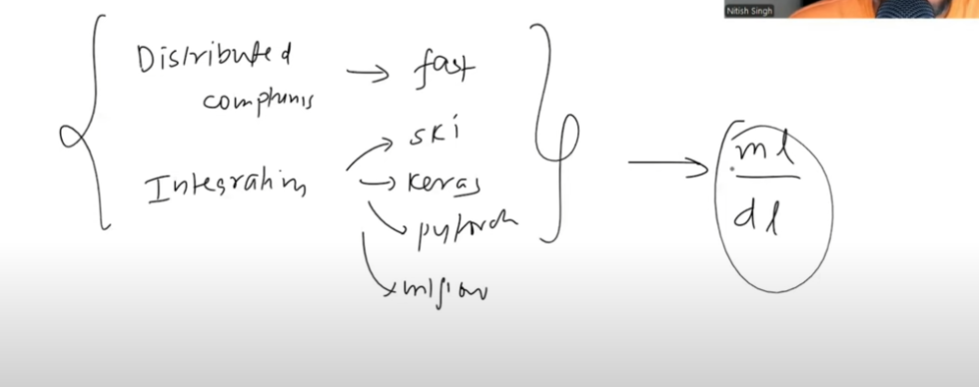